# Segment-Level Multimodal RAG for Audiovisual Reasoning

This notebook implements a segment-level multimodal retrieval and reasoning framework for long-form audio-visual datasets. Videos and audio are temporally segmented, embedded into a shared space using ImageBind, retrieved via cosine similarity, and reasoned over using Qwen2.5-Omni.

The objective is to retrieve temporally precise segments (“needles”) from large multi-video corpora (“haystacks”) and perform grounded multimodal reasoning.

---

### Pipeline Overview

#### 1. Dataset Preparation

* Integrity checks (video, audio, captions)
* Media renaming and QA filtering
* Standardization (H.264 video, PCM WAV audio)

#### 2. Temporal Segmentation

* Deterministic video/audio segmentation
* Caption alignment with timestamps
* Configurable segment lengths (e.g., 30s, 60s, 200s)

#### 3. Multimodal Embedding (ImageBind)

* Segment-level embeddings
* Shared text–audio–vision space
* Cosine similarity retrieval
* Local (per-topic) or global embedding banks
* Cached `.pt` embeddings for scalable experiments

#### 4. Audio-Visual Retrieval (AV-RAG)

* Text query → Top-K segment retrieval
* Configurable K
* Local vs global retrieval modes
* Supports temporal and multi-hop reasoning

#### 5. Frame-Level Evidence Attribution (SFS)

Salient Frame Selection (SFS) refines the top retrieved segment:

* Frame sampling within Top-1
* Multimodal fusion (vision ⊙ audio)
* Structured subset selection with diversity
* Comparison to naive Top-K frame scoring

SFS shifts retrieval from *segment-level relevance* to *moment-level evidence attribution*, improving interpretability.

#### 6. Multimodal Reasoning (Qwen2.5-Omni)

* Retrieved segments passed to Qwen Omni
* Structured prompting with relevance filtering
* Timestamp-grounded answers
* Batch GPU inference

#### 7. Meta-Agent Aggregation

To handle noisy retrieval:

* Multiple segments produce independent answers
* A meta-judge aggregates responses
* Irrelevant / “Unanswerable” outputs filtered
* Retrieval rank optionally weighted

This enables cross-segment comparison and controlled precision–recall trade-offs.


### Hierarchical Structure

```
Query → Segment Retrieval (AV-RAG) → Optional Frame Selection (SFS) → Segment-Level QA (Qwen Omni) → Meta-Agent Aggregation
```

The system is:

* Hierarchical
* Modular
* Interpretable across temporal scales
* Robust to retrieval noise

### Features

* Multi-topic dataset support
* Deterministic audio-visual alignment
* Shared multimodal embedding retrieval
* Local vs global bank comparison
* Temporal RAG for long-form video
* Qwen2.5-Omni integration
* Embedding caching for reproducibility
* Designed for multi-hop and cross-segment reasoning

## Dataset

This project uses a filtered subset of the **SONIC-O1** benchmark
([https://huggingface.co/datasets/vector-institute/sonic-o1](https://huggingface.co/datasets/vector-institute/sonic-o1)).

SONIC-O1 is a real-world multimodal benchmark for evaluating joint **audio–video understanding**. It contains 231 long-form conversational videos (~60 hours total) with synchronized video, audio, captions, and human-verified annotations across multiple tasks.

### Subset Used

We focus on **Task 2: Multiple-Choice QA (MCQ)** and use both the VQA annotations and corresponding media.

To ensure tractable segment-level retrieval, we restrict the dataset to:

* **Three domains**

  * Patient–Doctor Consultations
  * Job Interviews
  * Customer Service Interactions

* **Videos ≤ 120 seconds**

This filtered subset is used for segment-level multimodal retrieval and reasoning experiments (Audio-Visual RAG + Qwen2.5-Omni).

**License:** Vector Institute License.
Attribution: “Built with Vector Institute SONIC-O1.”


## Preprocessing data folder

Each folder within data refers to a topic of videos which would contain a audio/ video/ folder each along with a <topic>.json that contains the questions 

Before doing that, we need make sure each topic folder contains the following:
* `audio/` - Contains the audio files for each audio.
* `video/` - Contains the video files for each video.
* `caption/` - Contains the caption files for each video.
* `data/<topic>.json` - Contains the questions for each video in the topic.


In [1]:
import json  # To read and write JSON files
import os

from src.dataset_utils import (
    check_dataset_integrity,  # To check the integrity of the dataset (e.g., if all videos are present and not corrupted)
    filter_json_by_existing_videos,  # To filter the QA JSON file based on the existing videos in the dataset
    rename_media_files,  # To rename media files in a consistent format (e.g., video_001.mp4, video_002.mp4, etc.) for easier processing and organization
    simplify_mcq_json,  # To simplify the MCQ JSON file by removing unnecessary fields and keeping only the relevant information for training
)
from src.media_utils import list_video_durations  # To get the duration of each video in a folder

In [2]:
# To list the durations of all videos in the specified folder and filter out videos that are shorter than 120 seconds
list_video_durations(
    "data/Customer_Service_Interactions/video",  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
    120,
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/Customer_Service_Interactions/video'

In [ ]:
# To check the integrity of the dataset (e.g., if all videos are present and not corrupted)
check_dataset_integrity("data", vid_dir="video", aud_dir="audio", cap_dir="caption")

FileNotFoundError: [Errno 2] No such file or directory: 'data'

In [ ]:
# Rename media files in a consistent format for easier processing and organization
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
rename_media_files(f"data/{topic}/")


Renaming complete.


In [ ]:
print(f"data/{topic}/video")

data/Customer_Service_Interactions/video


In [ ]:
# Filter the QA JSON file based on the existing videos in the dataset
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
filter_json_by_existing_videos(
    json_path=f"data/{topic}.json",
    video_folder=f"data/{topic}/video",
    output_path=f"data/{topic}_filtered.json",
)

# Simplify the MCQ JSON file by removing unnecessary fields and keeping only the relevant information for training
with open(f"data/{topic}_filtered.json", "r") as f:
    data = json.load(f)

new_data = simplify_mcq_json(data)

with open(f"data/{topic}_filtered.json", "w") as f:
    json.dump(new_data, f, indent=2)

FileNotFoundError: [Errno 2] No such file or directory: 'data/Customer_Service_Interactions.json'

## Standardize Audios and Videos
The audios and videos are to be converted into a standardized format (H.264 for video and AAC for audio) while preserving the original quality as much as possible.

In [ ]:
from src.media_utils import process_audio, process_video

In [ ]:
def process_media(topic, max_duration=300):
    """
    Process video and audio files for a given topic.

    Parameters
    ----------
    - topic (str): The topic name (e.g., "Customer_Service_Interactions").
    - max_duration (int): Maximum duration for processing (default: 300 seconds).
    """
    VIDEO_DIR = f"data/{topic}/video"
    AUDIO_DIR = f"data/{topic}/audio"
    if max_duration is not None:
        VIDEO_PROCESS_DIR = f"data/{topic}/process-video_{max_duration}s"
        AUDIO_PROCESS_DIR = f"data/{topic}/process-audio_{max_duration}s"
    else:
        VIDEO_PROCESS_DIR = f"data/{topic}/process-video"
        AUDIO_PROCESS_DIR = f"data/{topic}/process-audio"

    # Run processing
    if VIDEO_DIR is not None:
        process_video(VIDEO_DIR, VIDEO_PROCESS_DIR, max_duration)

    if AUDIO_DIR is not None:
        process_audio(AUDIO_DIR, AUDIO_PROCESS_DIR, max_duration)

In [ ]:
# Example usage
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
process_media(topic=topic, max_duration=None)

FileNotFoundError: [Errno 2] No such file or directory: 'data/Customer_Service_Interactions/video'

## Split Audio and Video into segments for processing
The videos and audios are to be split into segments of a specified length (e.g., 30s, 60s, 200s) with an optional remainder merging strategy to ensure stable segment boundaries. The captions are also segmented based on their timestamps to align with the media segments.


In [ ]:
from src.dataset_utils import parse_srt_with_timestamps
from src.segmentation_utils import save_segmented_srt, split_audio, split_video

In [ ]:
def process_and_split_media(
    video_dir,
    audio_dir,
    caption_dir,
    segment_video_dir,
    segment_audio_dir,
    segment_caption_dir,
    segment_length=30,
    max_files=None,
):
    """
    Process and split video, audio, and captions into smaller segments.
    """
    os.makedirs(segment_video_dir, exist_ok=True)
    os.makedirs(segment_audio_dir, exist_ok=True)
    os.makedirs(segment_caption_dir, exist_ok=True)

    # ---- Split video ----
    if os.path.exists(video_dir):
        split_video(video_dir, segment_video_dir, segment_length, max_files=max_files)

    # ---- Split audio ----
    if os.path.exists(audio_dir):
        split_audio(audio_dir, segment_audio_dir, segment_length, max_files=max_files)

    # ---- Split captions ----
    if not os.path.exists(caption_dir):
        return

    segment_video_files = os.listdir(segment_video_dir)

    for filename in sorted(os.listdir(caption_dir)):
        if not filename.endswith(".srt"):
            continue

        video_id = os.path.splitext(filename)[0]

        total_segments = sum(1 for f in segment_video_files if f.startswith(video_id + "__") and f.endswith(".mp4"))

        print(f"{video_id} -> {total_segments} segments")

        if total_segments == 0:
            continue

        srt_path = os.path.join(caption_dir, filename)
        entries = parse_srt_with_timestamps(srt_path)

        save_segmented_srt(
            entries=entries,
            segment_length=segment_length,
            video_id=video_id,
            output_dir=segment_caption_dir,
            total_segments=total_segments,
        )

In [ ]:
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
base_dir = f"data/{topic}"
segment_length = 30
video_dir = os.path.join(base_dir, "process-video")
audio_dir = os.path.join(base_dir, "process-audio")
caption_dir = os.path.join(base_dir, "caption")

segment_video_dir = os.path.join(base_dir, f"segment-video_{segment_length}s")
segment_audio_dir = os.path.join(base_dir, f"segment-audio_{segment_length}s")
segment_caption_dir = os.path.join(base_dir, f"segment-caption_{segment_length}s")

process_and_split_media(
    video_dir=video_dir,
    audio_dir=audio_dir,
    caption_dir=caption_dir,
    segment_video_dir=segment_video_dir,
    segment_audio_dir=segment_audio_dir,
    segment_caption_dir=segment_caption_dir,
    segment_length=segment_length,
    # max_files=4
)

In [ ]:
check_dataset_integrity(
    "data",
    vid_dir="segment-video_30s",
    aud_dir="segment-audio_30s",
    cap_dir="segment-caption_30s",
)


Checking: Customer_Service_Interactions
  Total unique IDs: 0
  Matched triplets: 0
  Mismatches: 0
  All video-audio-caption triplets match.


## Audio-Visual Retrieval-Augmented Generation (AV-RAG)
AV-RAG is a retrieval-augmented generation framework designed for long-form audio-visual datasets. It retrieves relevant segments of audio and video based on a text query and then uses these segments to generate answers to questions.

In [ ]:
# sys.path.append("./src/ImageBind")
import json
import os
import shutil

import torch
from imagebind.models.imagebind_model import ModalityType
from src.model.avrag import AVRAG

In [ ]:
def run_avrag(
    model_path: str,
    annotations: str,
    output_path: str,
    video_vocabs: str,
    audio_vocabs: str,
    caption_vocabs: str,
    batch_size: int,
    use_cache: bool,
    topk: int,
    max_questions: int = None,
):
    """
    Run AVRAG retrieval on the given dataset.

    Args:
    - model_path (str): Path to the AVRAG model checkpoint.
    - annotations (str): Path to the JSON file containing questions.
    - output_path (str): Path to save the retrieval results.
    - video_vocabs (str): Path to video files or precomputed video embeddings.
    - audio_vocabs (str): Path to audio files or precomputed audio embeddings.
    - caption_vocabs (str): Path to caption files or precomputed caption embeddings.
    - batch_size (int): Batch size for encoding.
    - use_cache (bool): Whether to use precomputed embeddings.
    - topk (int): Number of top results to retrieve.
    - max_questions (int, optional): Maximum number of questions to process.
    """
    # ===== LOAD QUESTIONS =====
    with open(annotations, "r") as f:
        sources = json.load(f)

    if max_questions is not None:
        sources = sources[:max_questions]

    # ===== INITIALIZE RAG =====
    rag = AVRAG(model_path=model_path, bsz=batch_size)

    # ===== PREPARE MEDIA PATHS =====
    if use_cache:
        video_paths = os.path.join(video_vocabs, "video_embeddings.pt")
        audio_paths = os.path.join(audio_vocabs, "audio_embeddings.pt")
        caption_paths = os.path.join(caption_vocabs, "caption_embeddings.pt")
    else:
        video_paths = video_vocabs
        audio_paths = audio_vocabs
        caption_paths = caption_vocabs

    # ===== ENCODE MEDIA =====
    print("Encoding media...")

    v_embed = rag.encode(video_paths, ModalityType.VISION, cache=use_cache)
    a_embed = rag.encode(audio_paths, ModalityType.AUDIO, cache=use_cache)
    c_embed = rag.encode_srt_dir(caption_paths, cache=use_cache)

    # ===== RETRIEVAL =====
    print("Running retrieval...")
    targets = []

    for idx, source in enumerate(sources):
        question = source["question"]

        # Encode text
        t_embed = rag.encode([question], ModalityType.TEXT)

        # Joint AV + caption retrieval
        res = rag.joint_rag(
            query=t_embed,
            vocab_vision=v_embed,
            vocab_audio=a_embed,
            vocab_caption=c_embed,
            k=topk,
        )

        # Extract clean file IDs
        retrieved_ids = [item["file"] for item in res[0][t_embed["filename"][0]]]

        source["retrieved_file"] = retrieved_ids
        targets.append(source)

        print(f"[{idx + 1}/{len(sources)}] Retrieved: {retrieved_ids}")

    # ===== SAVE OUTPUT =====
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w") as f:
        json.dump(targets, f, indent=2)

    print("Finished retrieval. Saved to:", output_path)

### Build local embeddings for each topic
The local embeddings are built for each topic separately, allowing for more focused retrieval within the context of that specific topic.

In [ ]:
# Define the topic for processing
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
term = ""
suffix = "30s"

# Path to the pre-trained model checkpoint
MODEL_PATH = "checkpoints/imagebind_huge.pth"

# Path to the annotations file for the selected topic
ANNOTATIONS = f"data/{topic}_filtered.json"

# Path to save the output of the retrieval process
OUTPUT_PATH = f"output/{topic}_retrieved_{term}_{suffix}.json"

# Directories containing segmented video, audio, and caption files for the selected topic
VIDEO_VOCABS = f"data/{topic}/segment-video_{suffix}"
AUDIO_VOCABS = f"data/{topic}/segment-audio_{suffix}"
CAPTION_VOCABS = f"data/{topic}/segment-caption_{suffix}"

# Batch size for processing
BATCH_SIZE = 8

# Whether to use cached embeddings (set to True to use cache, False to recompute)
USE_CACHE = False

# Number of top-k results to retrieve
TOPK = 6

In [ ]:
# Run the AVRAG (Audio-Visual Retrieval and Generation) process
run_avrag(
    model_path=MODEL_PATH,  # Path to the pre-trained model checkpoint
    annotations=ANNOTATIONS,  # Path to the annotations file for the selected topic
    output_path=OUTPUT_PATH,  # Path to save the output of the retrieval process
    video_vocabs=VIDEO_VOCABS,  # Directory containing segmented video files
    audio_vocabs=AUDIO_VOCABS,  # Directory containing segmented audio files
    caption_vocabs=CAPTION_VOCABS,  # Directory containing segmented caption files
    batch_size=BATCH_SIZE,  # Batch size for processing
    use_cache=USE_CACHE,  # Whether to use cached embeddings or recompute them
    topk=TOPK,  # Number of top-k results to retrieve
    # max_questions=8,           # Maximum number of questions to process
)

### Build global embeddings across topics
The global embedding bank is constructed by processing all segments from all topics through the ImageBind model to obtain their multimodal embeddings. These embeddings are stored in a single global index for retrieval.

In [ ]:
def collect_files_from_dir(directory, extensions):
    """
    Collect files with specific extensions from a directory.

    Parameters
    ----------
    - directory (str): Path to the directory to search.
    - extensions (tuple): File extensions to include (e.g., (".mp4", ".wav")).

    Returns
    -------
    - list: List of file paths matching the specified extensions.
    """
    files = []
    for f in os.listdir(directory):
        if f.startswith("."):  # Skip hidden files
            continue
        full_path = os.path.join(directory, f)
        if os.path.isfile(full_path) and f.endswith(extensions):
            files.append(full_path)
    return files


def build_global_embeddings(
    root_data_dir,
    model_path,
    segment_suffix="30s",
    output_dir="data/global_embeddings",
):
    """
    Build global embeddings for video, audio, and captions across multiple topics.

    Parameters
    ----------
    - root_data_dir (str): Root directory containing topic subdirectories.
    - model_path (str): Path to the pre-trained model checkpoint.
    - segment_suffix (str): Suffix for segmented media directories (default: "30s").
    - output_dir (str): Directory to save the global embeddings (default: "data/global_embeddings").
    """
    os.makedirs(output_dir, exist_ok=True)

    # Initialize the AVRAG model
    rag = AVRAG(model_path=model_path, bsz=8)

    all_video_files = []  # List to store all video file paths
    all_audio_files = []  # List to store all audio file paths

    # Temporary directory to store all caption files
    temp_caption_dir = os.path.join(output_dir, "__all_captions_tmp")
    os.makedirs(temp_caption_dir, exist_ok=True)

    # Iterate through each topic in the root data directory
    for topic in os.listdir(root_data_dir):
        topic_path = os.path.join(root_data_dir, topic)

        # Skip non-directories and hidden topics
        if not os.path.isdir(topic_path) or topic.startswith("."):
            continue

        # Define paths for segmented media directories
        video_dir = os.path.join(topic_path, f"segment-video_{segment_suffix}")
        audio_dir = os.path.join(topic_path, f"segment-audio_{segment_suffix}")
        caption_dir = os.path.join(topic_path, f"segment-caption_{segment_suffix}")

        # Collect and copy video files
        if os.path.exists(video_dir):
            for f in os.listdir(video_dir):
                if f.endswith(".mp4"):
                    src = os.path.join(video_dir, f)
                    dst = os.path.join(output_dir, f"{topic}__{f}")
                    shutil.copy(src, dst)
                    all_video_files.append(dst)

        # Collect and copy audio files
        if os.path.exists(audio_dir):
            for f in os.listdir(audio_dir):
                if f.endswith((".wav", ".m4a")):
                    src = os.path.join(audio_dir, f)
                    dst = os.path.join(output_dir, f"{topic}__{f}")
                    shutil.copy(src, dst)
                    all_audio_files.append(dst)

        # Collect and copy caption files
        if os.path.exists(caption_dir):
            for f in os.listdir(caption_dir):
                if f.endswith(".srt"):
                    src = os.path.join(caption_dir, f)
                    dst = os.path.join(temp_caption_dir, f"{topic}__{f}")
                    shutil.copy(src, dst)

    # Encode video files
    print("Encoding videos...")
    video_embed = rag.encode(all_video_files, ModalityType.VISION, cache=False)

    # Encode audio files
    print("Encoding audio...")
    audio_embed = rag.encode(all_audio_files, ModalityType.AUDIO, cache=False)

    # Encode caption files
    print("Encoding captions...")
    caption_embed = rag.encode_srt_dir(temp_caption_dir, cache=False)

    # Save embeddings to the output directory
    torch.save(video_embed, os.path.join(output_dir, "video_embeddings.pt"))
    torch.save(audio_embed, os.path.join(output_dir, "audio_embeddings.pt"))
    torch.save(caption_embed, os.path.join(output_dir, "caption_embeddings.pt"))

    # Remove the temporary caption directory
    shutil.rmtree(temp_caption_dir)

    print("Global embeddings saved to:", output_dir)

In [ ]:
# Path to the pre-trained model checkpoint
MODEL_PATH = "checkpoints/imagebind_huge.pth"

# Build global embeddings for video, audio, and captions across all topics
build_global_embeddings(
    root_data_dir="data",  # Root directory containing topic subdirectories
    model_path=MODEL_PATH,  # Path to the pre-trained model checkpoint
    segment_suffix="30s",  # Suffix for segmented media directories
    output_dir="data/global_embeddings",  # Directory to save the global embeddings
)

Encoding videos...
Encoding audio...
Encoding captions...
Global embeddings saved to: ./data/global_embeddings


### To use global embeddings
The global embeddings are built across all the topics and stored in a single file. To use global embeddings, we load the global embedding file and perform retrieval across all topics.

In [ ]:
# ===== CONFIG =====

# Common Configuration
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
term = "global"
suffix = "30s"
BATCH_SIZE = 8
TOPK = 6
USE_CACHE = True  # IMPORTANT: now loading .pt files

# Paths
MODEL_PATH = "checkpoints/imagebind_huge.pth"
ANNOTATIONS = f"data/{topic}_filtered.json"
OUTPUT_PATH = f"output/{topic}_retrieved_{term}_{suffix}.json"

# Global Embeddings
GLOBAL_VOCABS = "data/global_embeddings"
VIDEO_VOCABS = GLOBAL_VOCABS
AUDIO_VOCABS = GLOBAL_VOCABS
CAPTION_VOCABS = GLOBAL_VOCABS

# Run AVRAG
run_avrag(
    model_path=MODEL_PATH,
    annotations=ANNOTATIONS,
    output_path=OUTPUT_PATH,
    video_vocabs=VIDEO_VOCABS,
    audio_vocabs=AUDIO_VOCABS,
    caption_vocabs=CAPTION_VOCABS,
    batch_size=BATCH_SIZE,
    use_cache=USE_CACHE,
    topk=TOPK,
)

### To use local embeddings
The local embeddings are built separately for each topic and stored in separate files. To use local embeddings, we load the embedding file for the specific topic we are interested in and perform retrieval within that topic.

In [ ]:
# ===== CONFIG =====
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
term = "local"
suffix = "30s"

BATCH_SIZE = 8
USE_CACHE = True  # IMPORTANT: now loading .pt files
TOPK = 6
# ALPHA_V = 1.0

MODEL_PATH = "checkpoints/imagebind_huge.pth"

ANNOTATIONS = f"data/{topic}_filtered.json"

OUTPUT_PATH = f"output/{topic}_retrieved_{term}_{suffix}.json"

# ---- LOCAL EMBEDDINGS ----
# If there is no cache
# VIDEO_VOCABS = f"data/{topic}/segment-video_{suffix}"
# AUDIO_VOCABS = f"data/{topic}/segment-audio_{suffix}"
# CAPTION_VOCABS = f"data/{topic}/segment-caption_{suffix}"

# If there is cache
LOCAL_VOCABS = f"data/{topic}/"
VIDEO_VOCABS = LOCAL_VOCABS
AUDIO_VOCABS = LOCAL_VOCABS
CAPTION_VOCABS = LOCAL_VOCABS


run_avrag(
    model_path=MODEL_PATH,
    annotations=ANNOTATIONS,
    output_path=OUTPUT_PATH,
    video_vocabs=VIDEO_VOCABS,
    audio_vocabs=AUDIO_VOCABS,
    caption_vocabs=CAPTION_VOCABS,
    batch_size=BATCH_SIZE,
    use_cache=USE_CACHE,  # must be True
    topk=TOPK,
)

Encoding media...
Running retrieval...
[1/7] Retrieved: ['002__000', '012__001', '011__000', '012__000', '008__001', '003__001']
[2/7] Retrieved: ['012__001', '002__000', '003__000', '003__001', '017__000', '017__002']
[3/7] Retrieved: ['010__002', '012__001', '003__000', '002__000', '015__000', '011__001']
[4/7] Retrieved: ['010__000', '010__002', '003__000', '012__001', '003__001', '002__000']
[5/7] Retrieved: ['012__001', '010__002', '008__001', '011__001', '017__000', '011__000']
[6/7] Retrieved: ['012__000', '012__001', '003__001', '010__001', '003__000', '017__000']
[7/7] Retrieved: ['008__001', '011__001', '003__000', '002__000', '015__000', '010__002']
Finished retrieval. Saved to: ./output/Customer_Service_Interactions_retrieved_local_30s.json


## Discussion: Local vs Global Embeddings

In a multimodal RAG pipeline, embeddings can be constructed either **per-topic (local)** or across all topics jointly (**global**).

### Local Embeddings

Local embeddings restrict retrieval to segments within a single topic. This reduces the search space, minimizes cross-topic noise, and typically improves retrieval accuracy. However, it assumes that the topic of the query is known beforehand, which limits realism. Performance in this setting may be inflated because irrelevant domains are excluded.

### Global Embeddings

Global embeddings combine all segments from all topics into a single shared embedding space. Retrieval is performed across the entire dataset, introducing cross-topic competition. This setting is more realistic and better reflects open-domain deployment scenarios. However, it is computationally heavier and generally results in lower retrieval accuracy due to increased difficulty.

### Practical Implications

Local retrieval is suitable for domain-specific systems and controlled evaluation. Global retrieval is preferable for open-domain systems and realistic benchmarking. In practice, evaluating both provides insight into domain-specific performance versus generalization capability.


## From Retrieval to Evidence Attribution: Salient Frame Selection

### 1. Motivation — Why Segment-Level Retrieval Is Not Enough

Joint AV-RAG retrieves the most relevant **video segment** for a given query. However, segments still contain:

- Redundant frames  
- Irrelevant temporal context  
- Diffuse multimodal signals  

For interpretability, we want to answer:

> Which exact moments inside the retrieved segment provide evidential support for the query?

Selecting salient frames transforms retrieval from:

- “Which clip is relevant?”  
to  
- “Which specific moments explain the answer?”

This creates a hierarchical retrieval pipeline:

**Query → Segment Retrieval → Frame-Level Evidence Selection → Reasoning / Answering**

---

### 2. Mathematical Formulation

Let the retrieved segment contain **m sampled frames**. For each sampled frame \(i\), we compute a fused audio–visual embedding:

$$
z_i = v_i \odot a_i
$$

where:
- vᵢ is the vision embedding  
- aᵢ is the audio embedding  
- ⊙ is the Hadamard (elementwise) product  

#### Similarity Matrix

We define a pairwise similarity term:

$$
\Gamma_{ab} = \cos(z_a, z_b)
$$

#### Temporal Diversity Penalty

To discourage selecting temporally clustered frames, we introduce a temporal penalty:

$$
\Delta_{ab} =
\begin{cases}
0 & \text{if } a=b \\
\gamma \cdot \frac{1}{\sin\left(\frac{\pi}{2}\lvert a-b\rvert\right)} & \text{if } a \neq b
\end{cases}
$$

where \(\gamma\) controls the strength of temporal regularization (larger \(\gamma\) encourages more spread-out evidence).

#### Combined Objective

$$
Q = \Gamma + \Delta
$$

We then select a set \(S\) of \(k\) frame indices to minimize the pairwise cost:

$$
S^{*} =
\arg\min_{S \subseteq \{1,\dots,m\},\, |S|=k}
\sum_{a \in S}\sum_{b \in S} Q_{ab}
$$

This differs from naive Top-\(k\) ranking (independent scoring) because it is a **joint optimization** over subsets of frames.

---

### 3. Interpretability Connection

SFS is not just a refinement step — it introduces structural interpretability.

#### (1) Sparse Evidence Allocation

We enforce a strict budget of \(k\) frames. This parallels:

- Sparse attention in transformers  
- Retrieval truncation in RAG  
- Tool / action selection in agents  

It constrains reasoning to a small, inspectable subset.

#### (2) Diversity-Aware Selection

Naive Top-\(k\):
- often selects redundant frames  
- is correlational and independent  

SFS:
- penalizes redundancy  
- encourages temporally distributed evidence  

This mirrors strategies used in multi-hop reasoning and diversity-promoting selection.

#### (3) Explicit Optimization Objective

Attention weights in LLMs are implicit and hard to audit directly. SFS makes the objective explicit and tunable:

$$
\gamma = 0 \Rightarrow \text{similarity-only selection}
$$

$$
\gamma > 0 \Rightarrow \text{diversity-regularized selection}
$$

This makes evidence selection controllable and inspectable.

---

### 4. Implementation

Steps:
1. Sample m frames from the top-1 retrieved video segment  
2. Encode each frame with ImageBind  
3. Encode aligned audio windows around each frame timestamp  
4. Fuse per-frame embeddings: zᵢ = vᵢ ⊙ aᵢ  
5. Build Q from Γ and Δ  
6. Use dynamic programming (Algorithm 1 in the paper) to select k frames

This operates strictly within the top retrieved segment, making the pipeline hierarchical.

---

### 5. Visualization

To inspect selection behavior, we visualize:

- The $Q$ matrix as a heatmap  
- The selected frame indices and corresponding frames  

By sweeping γ, we can observe:

- clustered selection (low γ)
- more spread-out evidence (high γ)

This provides a concrete, visual interpretability tool for multimodal retrieval systems.

In [ ]:
import os

from src.system_utils import get_aligned_paths

In [ ]:
topic = "Customer_Service_Interactions"
base_dir = f"data/{topic}"

video_dir = os.path.join(base_dir, "segment-video_30s")
audio_dir = os.path.join(base_dir, "segment-audio_30s")
caption_dir = os.path.join(base_dir, "segment-caption_30s")

rag = AVRAG(model_path="checkpoints/imagebind_huge.pth", bsz=16)

# Sample texts for testing based on the questions in the dataset
text_list = [
    "Find My iPhone",
    "Despite the customer's claims of being full after finishing a second serving of noodles, the chef insists on preparing a final rice dish, emphasizing it's part of 'Japanese culture.'",
    "Anna's money transfer",
]


video_paths, audio_paths, caption_paths = get_aligned_paths(video_dir, audio_dir, caption_dir)

### AV-Only
Retrieval using fused audio–visual embeddings without textual caption information.

In [ ]:
# Print a message indicating the start of encoding
print("Encoding...")

# Encode video, audio, and text embeddings using the AVRAG model
v_embed = rag.encode(video_paths, ModalityType.VISION)  # Encode video files
a_embed = rag.encode(audio_paths, ModalityType.AUDIO)  # Encode audio files
t_embed = rag.encode(text_list, ModalityType.TEXT)  # Encode text queries

# Print a message indicating the start of AV-only retrieval
print("\nRunning AV-only retrieval...")

# Create dictionaries mapping filenames to their respective embeddings for video and audio
mv = {f: e for f, e in zip(v_embed["filename"], v_embed["embeddings"])}  # Video embeddings
ma = {f: e for f, e in zip(a_embed["filename"], a_embed["embeddings"])}  # Audio embeddings

# Find the common filenames between video and audio embeddings
common = sorted(set(mv) & set(ma))

# Stack the embeddings for the common files into tensors and move them to the device
V = torch.stack([mv[f] for f in common]).to(rag.device)  # Video embeddings tensor
A = torch.stack([ma[f] for f in common]).to(rag.device)  # Audio embeddings tensor
q = t_embed["embeddings"].to(rag.device)  # Text query embeddings tensor

# Compute AV-only similarity scores between the text queries and the video-audio embeddings
scores = rag.compute_scores_av_only(q, V, A)

# Determine the number of top results to retrieve (minimum of 6 or the total number of scores)
k = min(6, scores.shape[-1])

# Retrieve the top-k scores and their corresponding indices
values, indices = torch.topk(scores, k=k, dim=-1)

# Initialize a list to store the AV-only retrieval results
j_res_av_only = []

# Iterate over each query to format the retrieval results
for q_idx in range(indices.shape[0]):
    results = []
    for rank in range(indices.shape[1]):
        idx = indices[q_idx, rank].item()  # Get the index of the top result
        results.append(
            {
                "rank": rank + 1,  # Rank of the result
                "file": common[idx],  # Filename of the retrieved segment
                "score": float(values[q_idx, rank]),  # Similarity score
            }
        )
    # Append the results for the current query
    j_res_av_only.append({t_embed["filename"][q_idx]: results})

# Print the retrieval results for each query
for result in j_res_av_only:
    print(result)

Encoding...


[h264 @ 0x55cf08587b80] mmco: unref short failure



Running AV-only retrieval...
{'text_0': [{'rank': 1, 'file': '012__002', 'score': 0.04935656860470772}, {'rank': 2, 'file': '012__001', 'score': 0.033208757638931274}, {'rank': 3, 'file': '002__000', 'score': 0.00621497817337513}, {'rank': 4, 'file': '017__002', 'score': 0.003439650870859623}, {'rank': 5, 'file': '008__001', 'score': 0.00213960325345397}, {'rank': 6, 'file': '017__000', 'score': 0.0012212932342663407}]}
{'text_1': [{'rank': 1, 'file': '017__000', 'score': 0.029768016189336777}, {'rank': 2, 'file': '017__002', 'score': 0.027808820828795433}, {'rank': 3, 'file': '011__000', 'score': 0.01991099864244461}, {'rank': 4, 'file': '015__000', 'score': 0.007459685672074556}, {'rank': 5, 'file': '012__001', 'score': 0.0059791323728859425}, {'rank': 6, 'file': '010__001', 'score': -0.0009557597804814577}]}
{'text_2': [{'rank': 1, 'file': '012__001', 'score': 0.06915178149938583}, {'rank': 2, 'file': '012__002', 'score': 0.062421880662441254}, {'rank': 3, 'file': '015__001', 'scor

### AV + Caption
Retrieval using fused audio–visual embeddings augmented with textual caption embeddings for semantic grounding.

In [ ]:
# Print a message indicating the start of encoding
print("Encoding...")

# Flag to determine whether to use cached embeddings or compute them from scratch
USE_CACHE = True  # Set to True to use precomputed embeddings, False to recompute

if USE_CACHE:
    # Load precomputed video embeddings from cache
    v_embed = rag.encode(f"data/{topic}/video_embeddings.pt", ModalityType.VISION, cache=True)

    # Load precomputed audio embeddings from cache
    a_embed = rag.encode(f"data/{topic}/audio_embeddings.pt", ModalityType.AUDIO, cache=True)

    # Load precomputed caption embeddings from cache
    c_embed = rag.encode(f"data/{topic}/caption_embeddings.pt", ModalityType.TEXT, cache=True)
else:
    # Compute video embeddings directly from video files
    v_embed = rag.encode(video_paths, ModalityType.VISION)

    # Compute audio embeddings directly from audio files
    a_embed = rag.encode(audio_paths, ModalityType.AUDIO)

    # Parse and compute caption embeddings directly from caption files
    texts = [rag._parse_srt(p) for p in caption_paths]
    c_embed = rag.encode(texts, ModalityType.TEXT)

    # Update filenames in the caption embeddings for alignment
    c_embed["filename"] = [os.path.splitext(os.path.basename(p))[0] for p in caption_paths]

# Encode the text queries directly (queries are typically small in size)
t_embed = rag.encode(text_list, ModalityType.TEXT)

# Print a message indicating the start of joint AV-RAG retrieval
print("\nRunning Joint AV-RAG retrieval...")

# Perform joint audio-visual retrieval augmented with captions
j_res = rag.joint_rag(t_embed, v_embed, a_embed, c_embed, k=6)

# Print the retrieval results for each query
for result in j_res:
    print(result)
    print("---")

Encoding...

Running Joint AV-RAG retrieval...
{'text_0': [{'rank': 1, 'file': '010__000', 'score': 0.30434831976890564}, {'rank': 2, 'file': '010__002', 'score': 0.23535412549972534}, {'rank': 3, 'file': '003__001', 'score': 0.2087872177362442}, {'rank': 4, 'file': '008__001', 'score': 0.1881857067346573}, {'rank': 5, 'file': '003__000', 'score': 0.18423767387866974}, {'rank': 6, 'file': '002__000', 'score': 0.1728801280260086}]}
---
{'text_1': [{'rank': 1, 'file': '002__000', 'score': 0.29034948348999023}, {'rank': 2, 'file': '012__000', 'score': 0.22065448760986328}, {'rank': 3, 'file': '011__000', 'score': 0.20462340116500854}, {'rank': 4, 'file': '012__001', 'score': 0.20134423673152924}, {'rank': 5, 'file': '003__001', 'score': 0.18084922432899475}, {'rank': 6, 'file': '008__001', 'score': 0.1743842512369156}]}
---
{'text_2': [{'rank': 1, 'file': '015__000', 'score': 0.23061375319957733}, {'rank': 2, 'file': '008__000', 'score': 0.18334949016571045}, {'rank': 3, 'file': '003__000

#### Caption Ablation Analysis

Removing caption embeddings leads to a substantial drop in retrieval performance. With captions, ground-truth segments appear at Rank 1 (2/3 queries) with strong similarity scores (~0.22–0.30). 

In contrast, AV-only retrieval produces near-zero similarity values and frequently fails to retrieve the correct segment within the top results.

This demonstrates that caption embeddings provide critical semantic grounding. The multimodal system relies heavily on textual alignment, while perceptual (vision + audio) signals alone are insufficient for abstract or entity-based queries.

### Frame-Level Evidence Analysis
This function performs structured frame-level attribution on the top retrieved segment.  

Given retrieval results, it:
- Samples candidate frames from the top-ranked segment
- Computes frame-level audio–visual embeddings
- Compares naive similarity ranking with Structured Frame Selection (SFS)
- Visualizes selected frames and the pairwise similarity matrix

The goal is to move from *segment-level retrieval* to *fine-grained evidence analysis*, identifying which specific frames contribute most to the model’s multimodal alignment.

In [ ]:
from src.inference import run_frame_evidence_analysis


================ Frame-Level Evidence Analysis ================

Query: text_0
Top-1 video: 010__000
Naive Top-K frames: [116, 174, 58, 0, 754]
SFS Selected frames: [0, 116, 464, 522, 870]


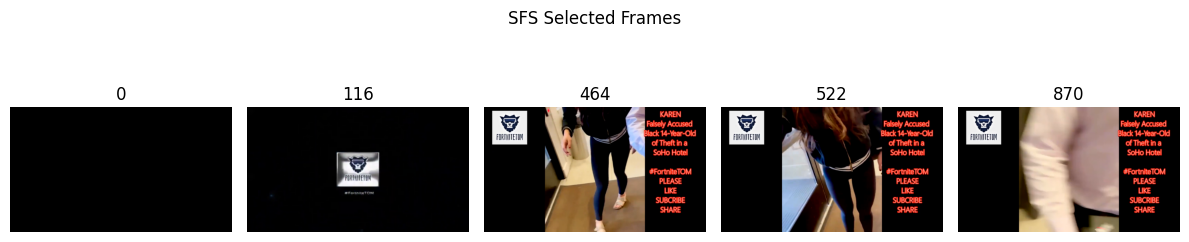

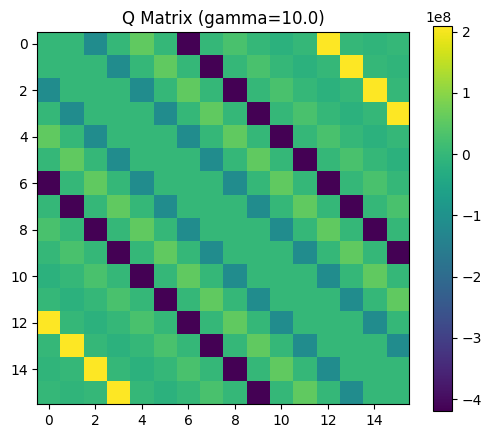


Query: text_1
Top-1 video: 002__000
Naive Top-K frames: [62, 814, 940, 438, 877]
SFS Selected frames: [0, 125, 501, 564, 940]


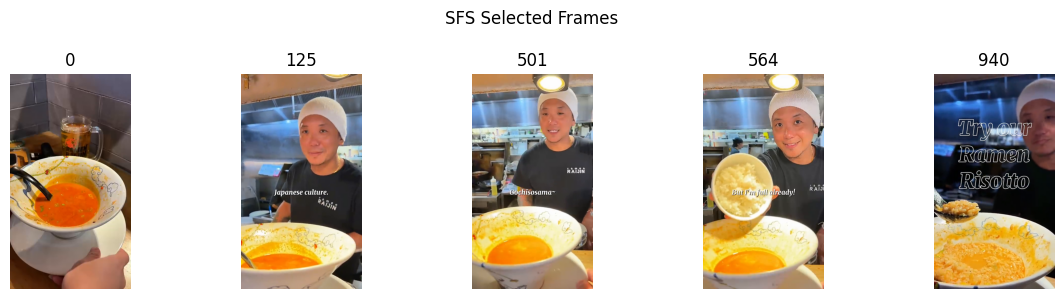

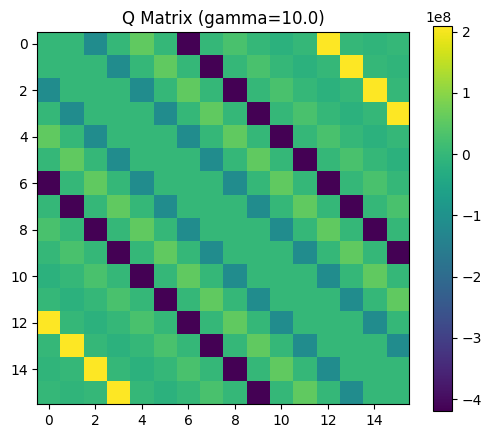


Query: text_2
Top-1 video: 015__000
Naive Top-K frames: [95, 47, 335, 287, 143]
SFS Selected frames: [0, 95, 383, 431, 719]


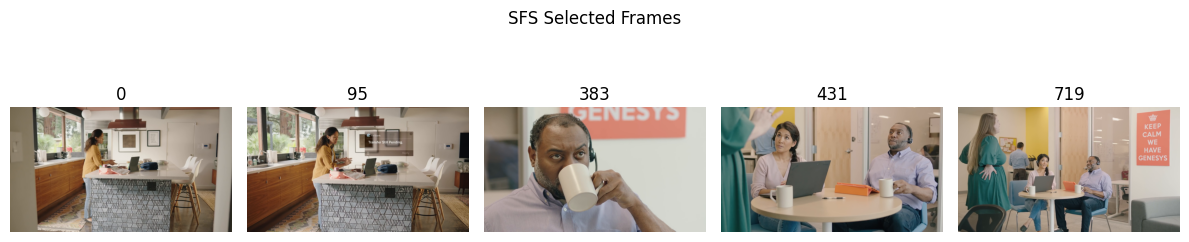

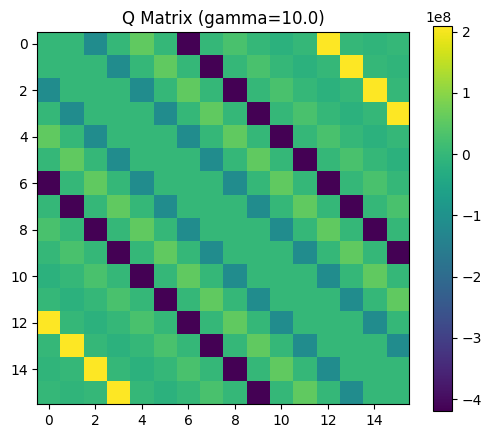

In [ ]:
run_frame_evidence_analysis(rag, j_res, t_embed, video_paths, audio_paths)

### Observations: Structured vs. Naive Frame Selection

The results highlight a clear difference between independent similarity ranking and structured evidence selection.

**Naive Top-K** selects frames purely based on query–frame similarity. This often produces temporally clustered frames that are visually similar and potentially redundant. The selection is correlational and local — each frame is ranked independently.

**SFS (γ > 0)** enforces a joint optimization objective that balances similarity with temporal diversity. The selected frames are more evenly distributed across the segment, reducing redundancy while preserving relevance. Once γ exceeds a moderate threshold (e.g., 5), the selection stabilizes, indicating that the temporal regularization term meaningfully shapes the solution.

The Q matrix visualizations confirm this behavior:

* The diagonal structure reflects cosine similarity between nearby frames.
* Off-diagonal structure emerges from the temporal penalty.
* Increasing γ amplifies diversity constraints.

Overall, SFS transforms frame selection from a purely similarity-driven process into a structured evidence allocation mechanism. This mirrors sparsity and regularization principles used in interpretable LLM reasoning, where limiting and structuring context improves inspectability and reduces redundancy.


## Run Inference
Inference is performed using Qwen2.5-Omni, which takes the retrieved segments from AV-RAG and generates answers to the questions based on the multimodal context.

Use ``Ref5 (Video QA)`` environment created as per ``README`` from this point of the notebook.

In [ ]:
import os


# Define base cache directory (modify as needed)
# BASE_CACHE_DIR = "<CACHE_DIR>"

# Uncomment and set specific cache directories as needed
# os.environ["TORCH_EXTENSIONS_DIR"] = f"{BASE_CACHE_DIR}/torch"

# Hugging Face cache directories
# HF_CACHE_DIR = "{BASE_DIR}/huggingface"
# os.environ["HF_HOME"] = HF_CACHE_DIR
# os.environ["TRANSFORMERS_CACHE"] = HF_CACHE_DIR
# os.environ["HUGGINGFACE_HUB_CACHE"] = HF_CACHE_DIR
# os.environ["HF_DATASETS_CACHE"] = HF_CACHE_DIR

print("Environment variables are commented. Uncomment when needed.")

Environment variables set.


In [ ]:
import json
import os
import time
import warnings

import torch
from src.inference import (
    process_question,  # To process a single question and generate an answer using the Qwen2_5OMNI model
)
from src.model.QwenOmni import Qwen2_5OMNI
from src.system_utils import print_gpu_memory


warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [ ]:
SYSTEM_PROMPT = """You are a multimodal analyst.
You are given synchronized video and audio content.

Follow this EXACT procedure:

Step 1 — Relevance Check:
If the question CANNOT be answered using the provided video and audio content, respond with EXACTLY:
Unanswerable
Do not add any explanation.

Step 2 — Answering:
If the question IS answerable:

• Provide a concise, factual answer.
• Base the answer strictly on the visible and audible content.
• Include supporting timestamps.
• Format timestamps EXACTLY as: [HH:MM:SS-HH:MM:SS]
• Use only timestamps that appear in the provided segment.
• Do NOT fabricate timestamps.
• Do NOT include reasoning steps.
• Do NOT mention that you analyzed video or audio.

Output Format:

Answer: <concise answer>
Evidence: [HH:MM:SS-HH:MM:SS]
"""

In [ ]:
def run_qwen_omni(
    model_name,
    retrieve_path,
    root_data_dir,
    segment_suffix,
    output_path,
    bsz,
    topic,
    max_questions: int = None,
):
    """
    Runs the Qwen Omni pipeline to process questions and generate answers.

    Args:
        model_name (str): Name of the model to use.
        retrieve_path (str): Path to the file containing questions and retrieved files.
        video_vocabs (str): Path to the directory containing video files.
        audio_vocabs (str): Path to the directory containing audio files.
        output_path (str): Path to save the output results.
        bsz (int): Batch size for processing.
        max_questions (int, optional): Maximum number of questions to process.

    Returns
    -------
        None
    """
    total_start = time.time()

    # Initialize Qwen only
    model = Qwen2_5OMNI(model_name=model_name, prompt=SYSTEM_PROMPT)

    # Load retrieved results
    with open(retrieve_path, "r") as f:
        sources = json.load(f)

    if max_questions is not None:
        sources = sources[:max_questions]

    targets = []
    question_times = []

    for source in sources:
        question_start = time.time()

        processed_source = process_question(source, root_data_dir, segment_suffix, model, bsz, topic)

        targets.append(processed_source)

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with open(output_path, "w") as f:
            json.dump(targets, f, indent=2)

        question_duration = time.time() - question_start
        question_times.append(question_duration)

        print(f"[Question Completed] {question_duration:.2f}s")
        print("-" * 50)

    total_time = time.time() - total_start
    avg_time = sum(question_times) / len(question_times) if question_times else 0

    with open(output_path, "w") as f:
        json.dump(targets, f, indent=2)

    print("\n" + "=" * 60)
    print("BOOTCAMP DEMO SUMMARY")
    print("=" * 60)
    print(f"Total Questions: {len(question_times)}")
    print(f"Average Time / Question: {avg_time:.2f}s")
    print(f"Total Runtime: {total_time:.2f}s")

    if torch.cuda.is_available():
        print_gpu_memory()

    print("=" * 60)

### Run Inference on Global Embeddings
The retrieved segments from the global embedding bank are passed to Qwen2.5-Omni for reasoning and answer generation.

In [ ]:
# ===== CONFIGURATION =====


# Model Configuration
MODEL_NAME = "Qwen/Qwen2.5-Omni-7B"  # Name of the model to use

# Topic Configuration
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"


# Ratio and Term Configuration
suffix = "30s"  # Ratio for processing (e.g., segment length, duration, etc.)
term = "global"  # Retrieval term (e.g., "newRAG", "full")

# File Paths for Input and Output
RETRIEVE_PATH = f"./output/{topic}_retrieved_{term}_{suffix}.json"  # Path to the retrieval file
OUTPUT_PATH = f"./output/{topic}_response_{term}_{suffix}.json"  # Path to save the output

# Vocabulary Directories
# VIDEO_VOCABS = f"data/{topic}/segment-video_{suffix}"  # Directory for segmented video files
# AUDIO_VOCABS = f"data/{topic}/segment-audio_{suffix}"  # Directory for segmented audio files
ROOT_DATA_DIR = "data"

# Batch Size for Processing
BATCH_SIZE = 8  # Number of items to process in a single batch

# Cache Directory
CACHE_DIR = "<path_to_cache_dir>"  # Path to the cache directory (update as needed)

# Maximum questions for processing
MAX_QUESTIONS = 8

# Run the Qwen Omni pipeline for processing questions and generating answers
run_qwen_omni(
    model_name=MODEL_NAME,
    retrieve_path=RETRIEVE_PATH,
    root_data_dir=ROOT_DATA_DIR,
    segment_suffix=suffix,
    output_path=OUTPUT_PATH,
    bsz=BATCH_SIZE,
    topic=topic,
    # max_questions=MAX_QUESTIONS,
)

### Run Inference on local embeddings
The retrieved segments from the local embedding bank are passed to Qwen2.5-Omni for reasoning and answer generation.

In [ ]:
# ===== CONFIGURATION =====

# Model Configuration
MODEL_NAME = "Qwen/Qwen2.5-Omni-7B"  # Name of the model to use
# Batch Size for Processing
BATCH_SIZE = 8  # Number of items to process in a single batch
# Cache Directory
CACHE_DIR = "<path_to_cache_dir>"  # Path to the cache directory (update as needed)


# Topic Configuration
topic = "Customer_Service_Interactions"  # "Patient-Doctor_Consultations" # "Job_Interviews" # "Customer_Service_Interactions"
# Ratio and Term Configuration
suffix = "30s"  # Ratio for processing (e.g., segment length, duration, etc.)
term = "local"  # Retrieval term (e.g., "newRAG", "full", "global", "local")

# File Paths for Input and Output
RETRIEVE_PATH = f"./output/{topic}_retrieved_{term}_{suffix}.json"  # Path to the retrieval file
OUTPUT_PATH = f"./output/{topic}_response_{term}_{suffix}.json"  # Path to save the output

# Vocabulary Directories
# VIDEO_VOCABS = f"data/{topic}/segment-video_{suffix}"  # Directory for segmented video files
# AUDIO_VOCABS = f"data/{topic}/segment-audio_{suffix}"  # Directory for segmented audio files
ROOT_DATA_DIR = "data"

# Maximum questions for processing
MAX_QUESTIONS = 8

# Run the Qwen Omni pipeline for processing questions and generating answers
run_qwen_omni(
    model_name=MODEL_NAME,
    retrieve_path=RETRIEVE_PATH,
    root_data_dir=ROOT_DATA_DIR,
    segment_suffix=suffix,
    output_path=OUTPUT_PATH,
    bsz=BATCH_SIZE,
    topic=topic,
    # max_questions=MAX_QUESTIONS,
)

### Retrieval Structure in Multimodal RAG Systems

We evaluate retrieval under two structural configurations:

* **Global embedding space**: all segments share a unified multimodal index.
* **Partitioned (local) embedding space**: retrieval is constrained to a subset of segments.

Rather than focusing on content differences, this analysis highlights how retrieval structure shapes system behavior.


#### 1. Semantic Similarity as the Primary Signal

In both configurations, retrieval is driven by embedding similarity. This naturally prioritizes segments that share:

* Conversational structure,
* Interaction patterns,
* Tone and communicative intent,
* Visual–audio scene characteristics.

This demonstrates that multimodal embeddings effectively encode high-level interaction semantics across diverse scenarios.

Retrieval consistently surfaces segments that are thematically aligned with the question’s setting.


#### 2. Global Space: Open Competition

In a unified embedding space:

* All segments compete within a single similarity landscape.
* Retrieval reflects how well the embedding model separates different interaction types.
* The system operates under a more open-world assumption.

This configuration evaluates the **separability and robustness of the embedding space** itself.

It reflects a realistic deployment setting where contextual boundaries are not pre-imposed.


#### 3. Partitioned Space: Structured Precision

In a partitioned retrieval setup:

* Candidate segments are pre-filtered structurally.
* Retrieval operates within a narrower semantic band.
* Top-K results are more context-consistent.

This configuration emphasizes **precision under constrained search** and reduces cross-context competition.

It simplifies the retrieval problem while maintaining multimodal alignment.


#### 4. Thematic Alignment vs Question Specificity

Across both settings, a clear pattern appears:

* Retrieval strongly captures interaction-level similarity.
* Question answering requires finer-grained alignment (e.g., specific statements, numerical details, or causal reasoning).

This illustrates an important distinction:

> Embedding similarity optimizes for semantic proximity, while answering accuracy depends on evidential specificity.

The interaction between these two levels determines downstream performance.


#### 5. Structural Insight

The comparison highlights that retrieval behavior is primarily shaped by:

* Embedding space organization,
* Index partitioning strategy,
* The granularity of the question,
* And the reasoning model’s ability to leverage retrieved evidence.

Global and partitioned retrieval are not simply better or worse — they represent different structural assumptions about how context is defined.

Understanding this distinction is central to designing robust multimodal RAG systems.

## Meta-agent to aggregate answers
Consolidates multiple segment-level predictions into a single final answer by filtering noise and prioritizing the most reliable evidence.

In [ ]:
import os
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [ ]:
from src.meta_agent import evaluate_diagnostics, run_meta_aggregation

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-Omni-7B"

topic = "Customer_Service_Interactions"
suffix = "30s"
term = "global"  # Change to "local" or "global" based on which result you'd like to test

INPUT_PATH = f"./output/{topic}_response_{term}_{suffix}.json"
META_OUTPUT_PATH = f"./output/{topic}_meta_{term}_{suffix}.json"

model = Qwen2_5OMNI(model_name=MODEL_NAME)

run_meta_aggregation(
    input_path=INPUT_PATH,
    output_path=META_OUTPUT_PATH,
    model=model,
    # version="v2", # Can be v0, v1, v2 based on prompt style (v2 by default)
)

In [ ]:
evaluate_diagnostics(META_OUTPUT_PATH)

### Observations

#### 1. Retrieval Enables — But Does Not Guarantee — Correct Answers

Even when the correct segment appears in the retrieved set, the final answer is not always correct.

This shows that:

* Retrieval controls **access to evidence**.
* Segment-level QA controls **how evidence is interpreted**.
* The meta-agent controls **which interpretations survive**.

Having relevant evidence available is necessary, but not sufficient.

---

#### 2. Signal vs. Noise Matters More Than Recall

In several cases, the correct segment is present among Top-K results, yet the final decision remains incorrect or “Not enough evidence.”

This indicates that performance depends not just on recall, but on:

* The strength of the correct reasoning signal
* The amount of competing noisy or irrelevant answers

Aggregation struggles when correct reasoning is weak and disagreement is high.

---

#### 3. Global vs Local Changes Noise Structure

Local retrieval tends to keep results within the same topic.
Global retrieval increases competition but introduces cross-topic noise.

This changes the distribution of segment answers and directly affects aggregation behavior.

The downstream reasoning module must therefore handle different types of interference depending on retrieval design.

---

### Interpretability Implication

Because the system is modular:

```
Query → Retrieval → Segment QA → Meta Aggregation
```

Failures can be localized:

* Retrieval failure → missing evidence
* QA failure → weak reasoning signal
* Aggregation failure → signal suppression

This structured pipeline makes the system auditable.
Rather than a single opaque prediction, we can inspect:

* What was retrieved
* How each segment reasoned
* Why the final answer was chosen

Interpretability here comes from **explicit intermediate reasoning stages**, not just final accuracy.


## Reflection & Concept Check

### 1. Retrieval Design

* **Q:** What is the core assumption behind using cosine similarity for multimodal retrieval?

  * **A:** That semantically related audio–visual segments lie close in a shared embedding space.

* **Q:** How does global retrieval differ structurally from partitioned retrieval?

  * **A:** Global retrieval allows all segments to compete in one space; partitioned retrieval restricts the candidate pool before similarity ranking.

* **Q:** What does Top-K control in the pipeline?

  * **A:** The trade-off between recall (higher K) and noise (lower precision).

* **Q:** Why might increasing Top-K improve downstream reasoning?

  * **A:** It increases the chance that the correct evidential segment is included in the candidate set.


### 2. Multimodal Embeddings

* **Q:** Why normalize embeddings before similarity search?

  * **A:** To ensure cosine similarity reflects angular distance rather than vector magnitude.

* **Q:** What does a shared embedding space enable?

  * **A:** Cross-modal alignment between video, audio, and text representations.

* **Q:** What limitation does embedding similarity inherently have?

  * **A:** It captures thematic similarity more reliably than fine-grained evidential detail.


### 3. Segmentation Strategy

* **Q:** Why segment long videos into fixed windows (e.g., 30s, 60s)?

  * **A:** To localize retrieval and reduce irrelevant temporal context.

* **Q:** What is the trade-off between shorter and longer segments?

  * **A:** Shorter segments improve localization but may lose context; longer segments preserve context but dilute precision.

* **Q:** Why filter by maximum duration before processing?

  * **A:** To maintain consistent computational cost and embedding quality.


### 4. Fusion & Weighting

* **Q:** What role does modality fusion play in the MAGNET pipeline?

  * **A:** It combines similarity signals from different modalities (e.g., audio and vision) to produce a unified retrieval score.

* **Q:** When might audio signals be more informative than visual signals?

  * **A:** In dialogue-driven or instruction-heavy interactions.

* **Q:** When might visual cues be more important than audio?

  * **A:** In demonstrations, physical procedures, or non-verbal interaction analysis.


### 5. Retrieval–Reasoning Interaction

* **Q:** Does strong retrieval performance automatically ensure correct answers?

  * **A:** No. Retrieval provides candidate evidence; reasoning determines how effectively it is used.

* **Q:** What happens when retrieval improves but reasoning remains unchanged?

  * **A:** Errors shift from missing evidence to misinterpreting available evidence.

* **Q:** Why inspect intermediate agent answers per retrieved segment?

  * **A:** To separate retrieval quality from reasoning quality.

* **Q:** What does MAGNET ultimately evaluate?

  * **A:** Whether multimodal similarity is sufficient to support grounded question answering.


### 6. Evaluation Logic

* **Q:** What does end-to-end accuracy reflect in this implementation?

  * **A:** The combined effectiveness of segmentation, embedding, retrieval, and reasoning.

* **Q:** Why compare global and partitioned retrieval settings?

  * **A:** To understand how embedding space structure influences retrieval behavior.

* **Q:** What structural factor most strongly shapes retrieval performance?

  * **A:** How well the embedding space separates semantically similar but contextually distinct segments.

* **Q:** What broader insight does this implementation provide?

  * **A:** That multimodal RAG performance depends on both embedding geometry and reasoning robustness.

## Final Reflection

The implementation demonstrates that multimodal RAG performance is not solely a reasoning problem or a retrieval problem, it is a structural interaction between:

* Segmentation granularity
* Embedding separability
* Similarity ranking
* Modality weighting
* And downstream reasoning behavior

Understanding these components as interacting design choices, rather than isolated modules, is key to building robust multimodal retrieval systems.

### References and Resources

1. **[MAGNET: A Multi-agent Framework for Finding Audio-Visual Needles by Reasoning over Multi-Video Haystacks](https://arxiv.org/abs/2506.07016)**  
    A comprehensive framework for temporal, causal, and multi-hop retrieval across long video haystacks.

2. **[VisRAG: Vision-based Retrieval-Augmented Generation on Multi-modality Documents](https://arxiv.org/abs/2410.10594)**  
    A study on retrieval-augmented generation leveraging vision-based multi-modal documents.

3. **[Videos Dataset for LLMs RAG](https://huggingface.co/datasets/elmoghany/Videos-Dataset-For-LLMs-RAG-That-Require-Audio-Vidoes-And-Text)**  
    A dataset designed for retrieval-augmented generation tasks requiring audio, video, and text.

4. **[SONIC-O1 Dataset](https://huggingface.co/datasets/vector-institute/sonic-o1)**  
    A dataset for audio-visual question answering tasks across various domains.